In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

from scripts.data_pipeline import main as data_processing
from scripts.train_pipeline import main as train_model
from src.utils import *

Matriz de correlação: 



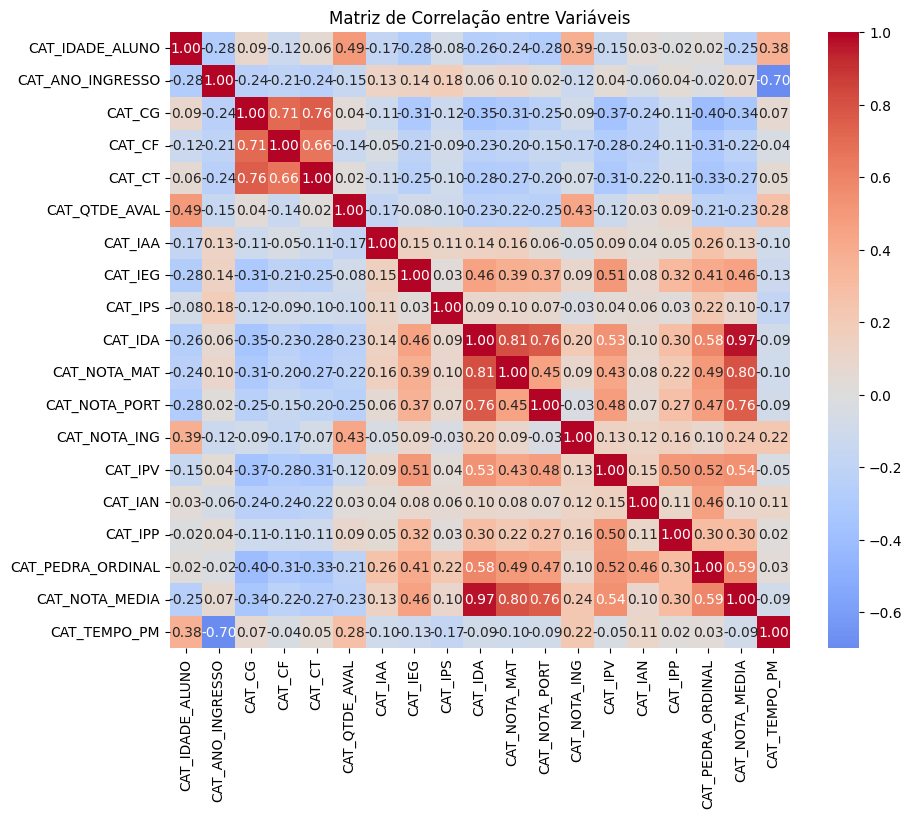

Variáveis altamente correlacionadas: 

        feature_1 feature_2  correlation
0    CAT_NOTA_MAT   CAT_IDA     0.812005
1  CAT_NOTA_MEDIA   CAT_IDA     0.969838

Features removidas por alta correlação: {'CAT_IDA'} e ['CAT_IAN']

Features finais: ['CAT_IDADE_ALUNO', 'CAT_ANO_INGRESSO', 'CAT_CG', 'CAT_CF', 'CAT_CT', 'CAT_QTDE_AVAL', 'CAT_IAA', 'CAT_IEG', 'CAT_IPS', 'CAT_NOTA_MAT', 'CAT_NOTA_PORT', 'CAT_NOTA_ING', 'CAT_IPV', 'CAT_IPP', 'CAT_PEDRA_ORDINAL', 'CAT_NOTA_MEDIA', 'CAT_TEMPO_PM']

Colunas categóricas finais: ['FASE', 'TURMA']

Colunas numéricas finais: ['CAT_IDADE_ALUNO', 'CAT_ANO_INGRESSO', 'CAT_CG', 'CAT_CF', 'CAT_CT', 'CAT_QTDE_AVAL', 'CAT_IAA', 'CAT_IEG', 'CAT_IPS', 'CAT_NOTA_MAT', 'CAT_NOTA_PORT', 'CAT_NOTA_ING', 'CAT_IPV', 'CAT_IPP', 'CAT_PEDRA_ORDINAL', 'CAT_NOTA_MEDIA', 'CAT_TEMPO_PM']

Iniciando treinamento do modelo...

Métricas do modelo base:
      metric     value
0   accuracy  0.685121
1  precision  0.729730
2     recall  0.505618
3   f1_score  0.597345
4    roc_a

In [2]:
train_model()

In [7]:
df

,NOTA_PORT,ANO_INGRESSO,PEDRA_ORDINAL,NOTA_MAT,IPS,IPV,TURMA,TEMPO_PM,IDADE_ALUNO,CF,QTDE_AVAL,IEG,NOTA_ING,IPP,CG,NOTA_MEDIA,IAA,CT,FASE
0,8.0,2022,1,7.0,7.1,6.5,A,5,20,7.8,4,6.8,7.0,7.0,8.5,7.5,7.5,8.2,2


In [ ]:
from src.feature_engineering import apply_numeric_binning
from pydantic import BaseModel

def log_prediction(data, prediction, probability):

    record = {
        "timestamp": str(datetime.now()),
        "input": data,
        "prediction": int(prediction),
        "probability": float(probability)
    }

    with open(PREDICTION_LOG, "a") as f:
        f.write(json.dumps(record) + "\n")


def update_metrics(probability):

    probability = float(probability)

    metrics["predictions_made"] += 1

    n = metrics["predictions_made"]
    old_avg = metrics["avg_probability"]

    metrics["avg_probability"] = ((old_avg*(n-1)) + probability)/n

class StudentInput(BaseModel):

    IDADE_ALUNO: int
    ANO_INGRESSO: int
    CG: float
    CF: float
    CT: float
    QTDE_AVAL: int
    IAA: float
    IEG: float
    IPS: float
    NOTA_MAT: float
    NOTA_PORT: float
    NOTA_ING: float
    IPV: float
    IPP: float
    PEDRA_ORDINAL: int
    NOTA_MEDIA: float
    TEMPO_PM: int
    FASE: str
    TURMA: str

    class Config:
        json_schema_extra = {
            "example": {
                "IDADE_ALUNO": 20,
                "ANO_INGRESSO": 2022,
                "CG": 8.5,
                "CF": 7.8,
                "CT": 8.2,
                "QTDE_AVAL": 4,
                "IAA": 7.5,
                "IEG": 6.8,
                "IPS": 7.1,
                "NOTA_MAT": 7.0,
                "NOTA_PORT": 8.0,
                "NOTA_ING": 7.0,
                "IPV": 6.5,
                "IPP": 7.0,
                "PEDRA_ORDINAL": 1,
                "NOTA_MEDIA": 7.5,
                "TEMPO_PM": 5,
                "FASE": "2",
                "TURMA": "A"
            }
        }

data = StudentInput(
    IDADE_ALUNO=20,
    ANO_INGRESSO=2022,
    CG=8.5,
    CF=7.8,
    CT=8.2,
    QTDE_AVAL=4,
    IAA=7.5,
    IEG=6.8,
    IPS=7.1,
    NOTA_MAT=7.0,
    NOTA_PORT=8.0,
    NOTA_ING=7.0,
    IPV=6.5,
    IPP=7.0,
    PEDRA_ORDINAL=1,
    NOTA_MEDIA=7.5,
    TEMPO_PM=5,
    FASE="2",
    TURMA="A"
)

payload = data.model_dump()

artifacts_dir = Path("../artifacts")

numeric_cols = load_list(artifacts_dir / "numeric_final.json")
categorical_cols = load_list(artifacts_dir / "categorical_final.json")

expected_features = list(set(numeric_cols + categorical_cols))

df = pd.DataFrame([payload])
df = df[expected_features]
df_model = apply_numeric_binning(df, load_dict(artifacts_dir / "binning_dict.json"))

MODEL_PATH = Path("../app/model/model_champion.joblib")
model = joblib.load(MODEL_PATH)

probability = model.predict_proba(df_model)[0][1]
prediction = int(probability >= 0.5)

probability

C:\Users\erick\AppData\Local\Temp\ipykernel_36336\4058490820.py:5: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class StudentInput(BaseModel):


0.7879058